# Chapter 1: Exploratory Data Analysis

This notebook reproduces the Python code from Chapter 1 of *Practical Statistics for Data Scientists* (2nd Edition) by Peter Bruce, Andrew Bruce, and Peter Gedeck.

The chapter introduces Exploratory Data Analysis (EDA), the first step in any data science project. It covers the types of structured data, estimates of location and variability, ways to visualize data distributions, methods for exploring binary and categorical data, and techniques for examining relationships between two or more variables.

In [2]:
from pathlib import Path

import pandas as pd
import numpy as np
from scipy.stats import trim_mean
from statsmodels import robust
import wquantiles

import seaborn as sns
import matplotlib.pyplot as plt

DATA = Path('data')

## 1. Elements of Structured Data

Data comes from many sources (sensors, transactions, text, images), and most of it starts out unstructured. A key step in data science is turning raw data into structured data that can be analyzed.

There are two basic types of structured data:

- **Numeric**: data expressed on a numeric scale.
  - *Continuous*: can take any value in an interval (e.g., temperature, wind speed).
  - *Discrete*: can only take integer values (e.g., number of occurrences of an event).
- **Categorical**: data that can only take a fixed set of values.
  - *Binary*: a special case with only two categories (e.g., yes/no, 0/1).
  - *Ordinal*: categories with an explicit order (e.g., a rating from 1 to 5).

Knowing the data type matters because it determines which visualizations, summaries, and statistical models are appropriate. In software, data types also help with storage efficiency and tell functions how to treat a variable.

## 2. Rectangular Data

The typical frame of reference for analysis in data science is **rectangular data**, such as a spreadsheet or a database table. In Python, this is represented by a pandas `DataFrame`.

Key terms:
- **Data frame**: a two-dimensional matrix with rows indicating records (cases) and columns indicating features (variables).
- **Feature**: a column in the table (also called attribute, input, predictor, or variable).
- **Outcome**: the variable we want to predict (also called dependent variable, response, or target).
- **Record**: a row in the table (also called case, example, instance, or observation).

Not all data is rectangular. Other structures include time series data, spatial data, and graph (network) data, which require different representations and methods.

In [3]:
state = pd.read_csv(DATA / 'state.csv')
print('Shape (rows, columns):', state.shape)
print()
print(state.dtypes)

Shape (rows, columns): (50, 4)

State               str
Population        int64
Murder.Rate     float64
Abbreviation        str
dtype: object


## 3. Estimates of Location

A basic step in exploring data is finding a "typical value" for each feature, an estimate of where most of the data is located (its central tendency).

- **Mean**: the sum of all values divided by the number of values. It is simple but sensitive to extreme values (outliers).
- **Trimmed mean**: the mean after dropping a fixed proportion of the smallest and largest values. For example, a 10% trimmed mean removes the bottom 10% and top 10% before averaging. This reduces the influence of outliers.
- **Median**: the middle value of the sorted data. It depends only on the values in the center, so it is **robust** to outliers.
- **Weighted mean / weighted median**: used when some records should count more than others. For example, when averaging state murder rates, larger states should carry more weight because they represent more people.

An estimate is called **robust** if it is not strongly affected by extreme values.

In [4]:
state.head(8)

,State,Population,Murder.Rate,Abbreviation
0,Alabama,4779736,5.7,AL
1,Alaska,710231,5.6,AK
2,Arizona,6392017,4.7,AZ
3,Arkansas,2915918,5.6,AR
4,California,37253956,4.4,CA
5,Colorado,5029196,2.8,CO
6,Connecticut,3574097,2.4,CT
7,Delaware,897934,5.8,DE


In [5]:
print('Mean:', state['Population'].mean())
print('Trimmed mean (10%):', trim_mean(state['Population'], 0.1))
print('Median:', state['Population'].median())

Mean: 6162876.3
Trimmed mean (10%): 4783697.125
Median: 4436369.5


The mean is noticeably larger than the trimmed mean and the median. This is because a few states with very large populations (such as California and Texas) pull the mean upward. The trimmed mean and median are less affected by these extreme values.

In [6]:
print('Weighted mean murder rate:', np.average(state['Murder.Rate'], weights=state['Population']))
print('Weighted median murder rate:', wquantiles.median(state['Murder.Rate'], weights=state['Population']))

Weighted mean murder rate: 4.445833981123393
Weighted median murder rate: 4.4


Weighting by population gives a murder rate that better reflects the experience of the average person in the US, rather than the average state.

## 4. Estimates of Variability

Location is only one dimension of a distribution. **Variability** (or dispersion) measures how spread out or clustered the values are.

- **Deviations**: the differences between observed values and an estimate of location.
- **Variance**: the sum of squared deviations from the mean divided by n - 1.
- **Standard deviation**: the square root of the variance. It is on the same scale as the original data, which makes it easier to interpret. Like the mean, it is sensitive to outliers.
- **Mean absolute deviation**: the mean of the absolute deviations from the mean.
- **Median absolute deviation (MAD)**: the median of the absolute deviations from the median. It is a robust measure of variability. The statsmodels implementation scales it by a constant so it is comparable to the standard deviation for normally distributed data.
- **Range**: the difference between the largest and smallest values. Very sensitive to outliers.
- **Percentile**: the value below which a given percentage of the data falls.
- **Interquartile range (IQR)**: the difference between the 75th and 25th percentiles. A robust measure of spread.

The use of n - 1 instead of n in the variance is related to **degrees of freedom**: it makes the sample variance an unbiased estimate of the population variance.

In [7]:
print('Standard deviation:', state['Population'].std())
print('IQR:', state['Population'].quantile(0.75) - state['Population'].quantile(0.25))
print('MAD (statsmodels):', robust.scale.mad(state['Population']))
print('MAD (manual):', abs(state['Population'] - state['Population'].median()).median() / 0.6744897501960817)

Standard deviation: 6848235.347401142
IQR: 4847308.0
MAD (statsmodels): 3849876.1459979336
MAD (manual): 3849876.1459979336


The standard deviation is much larger than the MAD because it is influenced by the few very large states. The two MAD calculations give the same result, since the statsmodels function divides the raw median absolute deviation by about 0.6745.

## 5. Exploring the Data Distribution

Summary numbers alone can hide important patterns, so it is useful to look at how the data is distributed overall.

### 5.1 Percentiles and Boxplots

Percentiles summarize the tails of a distribution. A **boxplot** is a compact visual summary based on percentiles:
- The box spans from the 25th to the 75th percentile (the IQR).
- The line inside the box is the median.
- The whiskers extend to the furthest points within 1.5 times the IQR from the box.
- Points beyond the whiskers are plotted individually as potential outliers.

In [8]:
state['Murder.Rate'].quantile([0.05, 0.25, 0.5, 0.75, 0.95])

0.05    1.600
0.25    2.425
0.50    4.000
0.75    5.550
0.95    6.510
Name: Murder.Rate, dtype: float64

In [9]:
percentages = [0.05, 0.25, 0.5, 0.75, 0.95]
df = pd.DataFrame(state['Murder.Rate'].quantile(percentages))
df.index = [f'{p * 100}%' for p in percentages]
df.transpose()

,5.0%,25.0%,50.0%,75.0%,95.0%
Murder.Rate,1.6,2.425,4.0,5.55,6.51


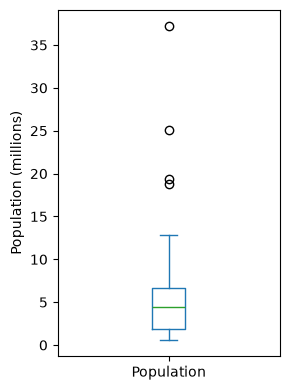

In [10]:
ax = (state['Population'] / 1_000_000).plot.box(figsize=(3, 4))
ax.set_ylabel('Population (millions)')
plt.tight_layout()
plt.show()

The median state population is around 5 million, and half of the states fall roughly between 2 and 7 million. Several states with very high populations appear above the upper whisker as outliers.

### 5.2 Frequency Tables and Histograms

A **frequency table** divides the range of a variable into equally spaced segments (bins) and counts how many values fall into each one. A **histogram** is the visual version of a frequency table, with bins on the x-axis and counts on the y-axis.

The number and size of bins matter: too few bins can hide important features, while too many bins can make the plot noisy.

In [11]:
binnedPopulation = pd.cut(state['Population'], 10)
binnedPopulation.value_counts().sort_index()

Population
(526935.67, 4232659.0]      24
(4232659.0, 7901692.0]      14
(7901692.0, 11570725.0]      6
(11570725.0, 15239758.0]     2
(15239758.0, 18908791.0]     1
(18908791.0, 22577824.0]     1
(22577824.0, 26246857.0]     1
(26246857.0, 29915890.0]     0
(29915890.0, 33584923.0]     0
(33584923.0, 37253956.0]     1
Name: count, dtype: int64

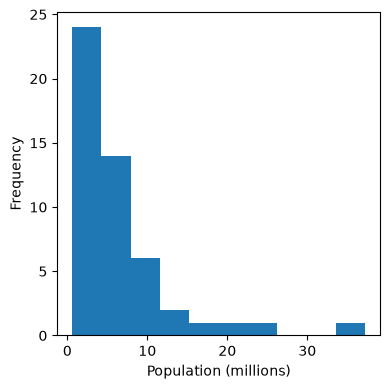

In [12]:
ax = (state['Population'] / 1_000_000).plot.hist(figsize=(4, 4))
ax.set_xlabel('Population (millions)')
plt.tight_layout()
plt.show()

The histogram is right-skewed: most states have relatively small populations, with a long tail of a few very large states. Some bins are empty, which is also informative about the shape of the data.

### 5.3 Density Plots and Estimates

A **density plot** can be thought of as a smoothed histogram. It is computed directly from the data using a **kernel density estimate (KDE)**. On a density plot, the y-axis shows proportions rather than counts, so the total area under the curve equals 1.

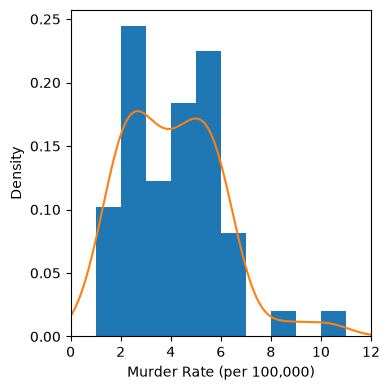

In [13]:
ax = state['Murder.Rate'].plot.hist(density=True, xlim=[0, 12], bins=range(1, 12), figsize=(4, 4))
state['Murder.Rate'].plot.density(ax=ax)
ax.set_xlabel('Murder Rate (per 100,000)')
plt.tight_layout()
plt.show()

## 6. Exploring Binary and Categorical Data

For categorical data, simple proportions or percentages usually tell the story.

- **Mode**: the most commonly occurring category or value.
- **Expected value**: when categories can be associated with numeric values, the expected value is the sum of each value multiplied by its probability of occurrence. It is often used in business decisions.
- **Bar chart**: shows the frequency or proportion of each category as a bar.
- **Pie chart**: also shows proportions, but is generally considered less effective than a bar chart for comparing values.

Note the difference between a bar chart and a histogram: in a bar chart, the x-axis represents separate categories, while in a histogram the x-axis represents values of a single numeric variable.

The example below uses the percentage of flight delays at Dallas/Fort Worth Airport by cause.

In [14]:
dfw = pd.read_csv(DATA / 'dfw_airline.csv')
dfw

,Carrier,ATC,Weather,Security,Inbound
0,64263.16,84856.5,11235.42,343.15,118427.82


In [15]:
100 * dfw / dfw.values.sum()

,Carrier,ATC,Weather,Security,Inbound
0,23.022989,30.400781,4.025214,0.122937,42.428079


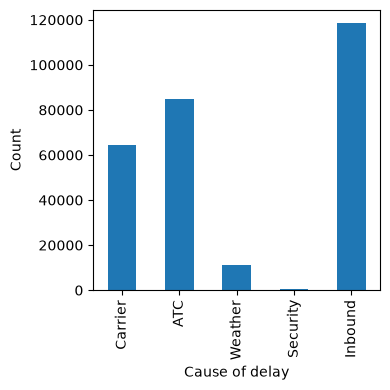

In [16]:
ax = dfw.transpose().plot.bar(figsize=(4, 4), legend=False)
ax.set_xlabel('Cause of delay')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

The bar chart makes it easy to see which delay causes are most common. The mode of this data is the delay cause with the highest count.

As an example of expected value: suppose a company offers two levels of subscription, $300 per month and $50 per month, and expects 5% of new visitors to sign up for the $300 plan, 15% for the $50 plan, and 80% to sign up for nothing.

In [17]:
expected_value = 0.05 * 300 + 0.15 * 50 + 0.80 * 0
print('Expected value per visitor:', expected_value)

Expected value per visitor: 22.5


## 7. Correlation

Exploratory analysis often involves examining the relationship between pairs of variables.

- **Correlation coefficient** (Pearson's r): measures how strongly two numeric variables are linearly related. It ranges from -1 (perfect negative relationship) to +1 (perfect positive relationship), with 0 meaning no linear relationship.
- **Correlation matrix**: a table showing the correlation between every pair of variables.
- **Scatterplot**: a plot with one variable on the x-axis and another on the y-axis, where each point is a record.

Like the mean and standard deviation, Pearson's correlation is sensitive to outliers. It also only captures linear relationships, so two variables can be strongly related in a nonlinear way and still have a correlation close to 0.

The examples below use daily stock returns of S&P 500 companies.

In [18]:
sp500_sym = pd.read_csv(DATA / 'sp500_sectors.csv')
sp500_px = pd.read_csv(DATA / 'sp500_data.csv.gz', index_col=0)

In [19]:
telecomSymbols = sp500_sym[sp500_sym['sector'] == 'telecommunications_services']['symbol']
telecom = sp500_px.loc[sp500_px.index >= '2012-07-01', telecomSymbols]
telecom.corr()

,T,CTL,FTR,VZ,LVLT
T,1.000000,0.474683,0.327767,0.677612,0.278626
CTL,0.474683,1.000000,0.419757,0.416604,0.286665
FTR,0.327767,0.419757,1.000000,0.287386,0.260068
VZ,0.677612,0.416604,0.287386,1.000000,0.242199
LVLT,0.278626,0.286665,0.260068,0.242199,1.000000


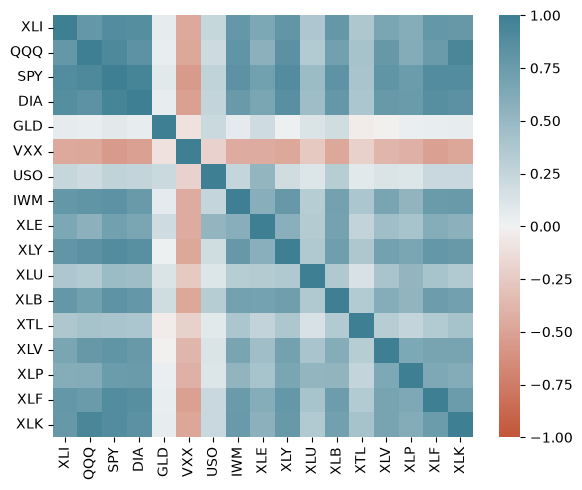

In [20]:
etfs = sp500_px.loc[sp500_px.index > '2012-07-01',
                    sp500_sym[sp500_sym['sector'] == 'etf']['symbol']]

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(etfs.corr(), vmin=-1, vmax=1,
            cmap=sns.diverging_palette(20, 220, as_cmap=True), ax=ax)
plt.tight_layout()
plt.show()

The heatmap shows the correlation matrix for ETF returns. Most ETFs that track the stock market are strongly positively correlated with each other. ETFs that track other assets, such as gold or volatility, show weaker or negative correlations with the rest.

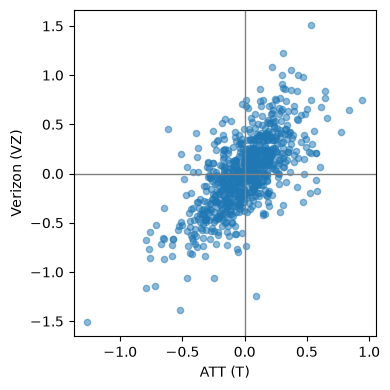

In [21]:
ax = telecom.plot.scatter(x='T', y='VZ', figsize=(4, 4), marker='o', alpha=0.5)
ax.set_xlabel('ATT (T)')
ax.set_ylabel('Verizon (VZ)')
ax.axhline(0, color='grey', lw=1)
ax.axvline(0, color='grey', lw=1)
plt.tight_layout()
plt.show()

The scatterplot shows a positive relationship between the daily returns of AT&T and Verizon: on most days, both stocks move in the same direction. Most points are concentrated around zero, which means daily returns are usually small.

## 8. Exploring Two or More Variables

Familiar estimators like the mean and variance look at one variable at a time (**univariate analysis**). Correlation looks at two variables (**bivariate analysis**). This section looks at techniques for two or more variables (**multivariate analysis**).

### 8.1 Hexagonal Binning and Contours (Numeric vs Numeric)

Scatterplots work well for small datasets, but with hundreds of thousands of records the points overlap too much to be useful. Alternatives:
- **Hexagonal binning**: groups records into hexagonal bins and colors each bin by the number of records in it.
- **Contour plot**: shows the density of two variables like a topographical map, where each contour line represents a constant density level.

The example uses tax-assessed values of residential properties in King County, Washington. Extreme values are removed first so the plots focus on the main body of the data.

In [22]:
kc_tax = pd.read_csv(DATA / 'kc_tax.csv.gz')
kc_tax0 = kc_tax.loc[(kc_tax.TaxAssessedValue < 750000) &
                     (kc_tax.SqFtTotLiving > 100) &
                     (kc_tax.SqFtTotLiving < 3500), :]
kc_tax0.shape

(432693, 3)

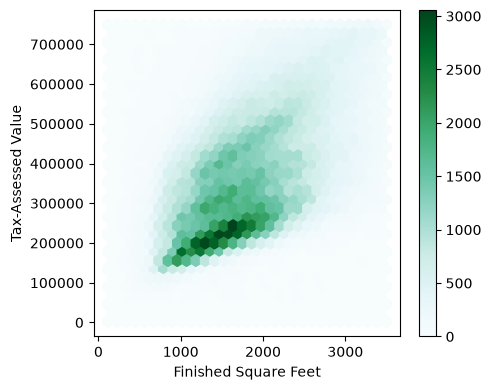

In [23]:
ax = kc_tax0.plot.hexbin(x='SqFtTotLiving', y='TaxAssessedValue',
                         gridsize=30, figsize=(5, 4))
ax.set_xlabel('Finished Square Feet')
ax.set_ylabel('Tax-Assessed Value')
plt.tight_layout()
plt.show()

The hexbin plot shows a positive relationship between square footage and tax-assessed value: larger homes tend to have higher values. The darkest region shows where most homes are concentrated.

For the contour plot, a random sample of 10,000 records is used because computing a kernel density estimate on the full dataset would be very slow.

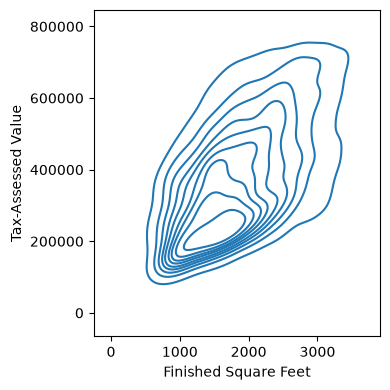

In [24]:
fig, ax = plt.subplots(figsize=(4, 4))
sns.kdeplot(data=kc_tax0.sample(10000, random_state=1),
            x='SqFtTotLiving', y='TaxAssessedValue', ax=ax)
ax.set_xlabel('Finished Square Feet')
ax.set_ylabel('Tax-Assessed Value')
plt.tight_layout()
plt.show()

### 8.2 Two Categorical Variables

A **contingency table** is a useful way to summarize two categorical variables. It shows the count of records for each combination of categories.

The example uses personal loan data from Lending Club, comparing the loan grade (A is the best, G is the worst) with the loan status.

In [25]:
lc_loans = pd.read_csv(DATA / 'lc_loans.csv')
crosstab = pd.crosstab(lc_loans['grade'], lc_loans['status'], margins=True)
crosstab

status,Charged Off,Current,Fully Paid,Late,All
grade,,,,,
A,1562,50051,20408,469,72490
B,5302,93852,31160,2056,132370
C,6023,88928,23147,2777,120875
D,5007,53281,13681,2308,74277
E,2842,24639,5949,1374,34804
F,1526,8444,2328,606,12904
G,409,1990,643,199,3241
All,22671,321185,97316,9789,450961


In [26]:
pd.crosstab(lc_loans['grade'], lc_loans['status'], normalize='index').round(3)

status,Charged Off,Current,Fully Paid,Late
grade,,,,
A,0.022,0.690,0.282,0.006
B,0.040,0.709,0.235,0.016
C,0.050,0.736,0.191,0.023
D,0.067,0.717,0.184,0.031
E,0.082,0.708,0.171,0.039
F,0.118,0.654,0.180,0.047
G,0.126,0.614,0.198,0.061


The second table shows the proportion of each loan status within each grade. Lower-grade loans (toward G) have a higher proportion of loans that are charged off or late, which matches the idea that the grade reflects credit risk.

### 8.3 Categorical and Numeric Data

Boxplots can be used to compare the distribution of a numeric variable across categories. A **violin plot** is an enhancement of the boxplot that also shows the density estimate on each side, so it can reveal the shape of the distribution (such as multiple peaks) that a boxplot would hide.

The example compares the percentage of flights delayed due to the carrier across several airlines.

In [27]:
airline_stats = pd.read_csv(DATA / 'airline_stats.csv')
airline_stats.head()

,pct_carrier_delay,pct_atc_delay,pct_weather_delay,airline
0,8.153226,1.971774,0.762097,American
1,5.959924,3.706107,1.585878,American
2,7.157270,2.706231,2.026706,American
3,12.100000,11.033333,0.000000,American
4,7.333333,3.365591,1.774194,American


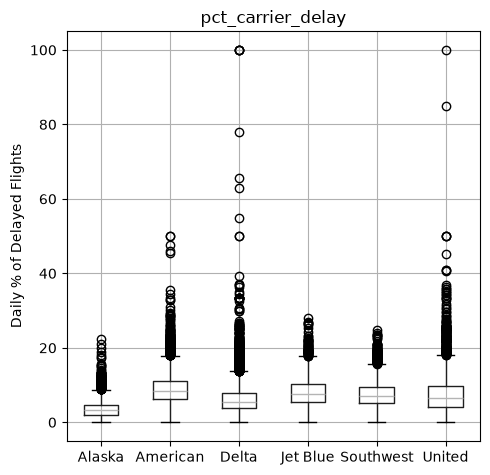

In [28]:
ax = airline_stats.boxplot(by='airline', column='pct_carrier_delay', figsize=(5, 5))
ax.set_xlabel('')
ax.set_ylabel('Daily % of Delayed Flights')
plt.suptitle('')
plt.tight_layout()
plt.show()

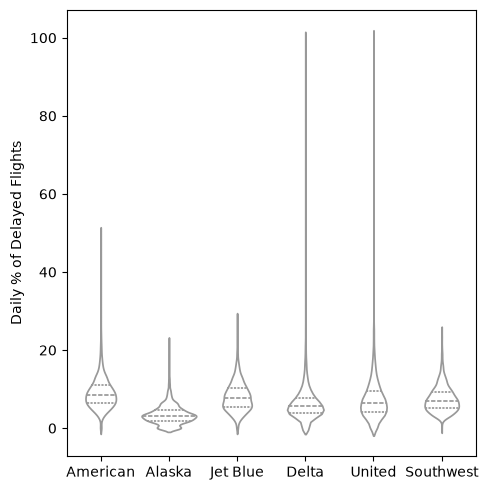

In [29]:
fig, ax = plt.subplots(figsize=(5, 5))
sns.violinplot(data=airline_stats, x='airline', y='pct_carrier_delay',
               ax=ax, inner='quartile', color='white')
ax.set_xlabel('')
ax.set_ylabel('Daily % of Delayed Flights')
plt.tight_layout()
plt.show()

Some airlines have a noticeably higher median carrier delay than others. The violin plot additionally shows where values are concentrated, for example whether most days have low delays with a long tail of bad days.

### 8.4 Visualizing Multiple Variables

The same plots can be extended to more than two variables using **conditioning**: creating the same plot for different subsets of the data defined by a third variable. Below, the hexbin plot of square footage vs tax-assessed value is repeated for four different zip codes.

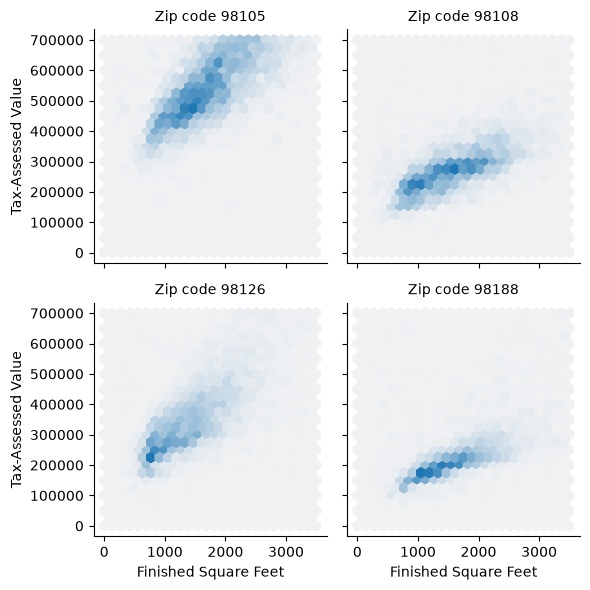

In [30]:
zip_codes = [98188, 98105, 98108, 98126]
kc_tax_zip = kc_tax0.loc[kc_tax0.ZipCode.isin(zip_codes), :]

def hexbin(x, y, color, **kwargs):
    cmap = sns.light_palette(color, as_cmap=True)
    plt.hexbin(x, y, gridsize=25, cmap=cmap, **kwargs)

g = sns.FacetGrid(kc_tax_zip, col='ZipCode', col_wrap=2)
g.map(hexbin, 'SqFtTotLiving', 'TaxAssessedValue', extent=[0, 3500, 0, 700000])
g.set_axis_labels('Finished Square Feet', 'Tax-Assessed Value')
g.set_titles('Zip code {col_name:.0f}')
plt.show()

The relationship between size and value differs by zip code. In some areas, homes of the same size are assessed at much higher values than in others, which shows that location is an important factor that a single overall plot would hide.

## Summary

Exploratory Data Analysis is the foundation of any data science project. Before building models, it is important to understand what the data looks like.

Key takeaways from this chapter:
- Data can be numeric (continuous or discrete) or categorical (binary or ordinal), and the type determines which methods are appropriate.
- Most analysis is done on rectangular data, represented in Python as a pandas DataFrame.
- The mean is a simple estimate of location, but robust alternatives like the median and trimmed mean are less affected by outliers. Weighted estimates are useful when records should not count equally.
- Variability can be measured with the standard deviation, or with robust measures such as the MAD and IQR.
- Boxplots, histograms, and density plots reveal the shape of a distribution, including skewness and outliers.
- For categorical data, proportions, bar charts, mode, and expected value are the main tools.
- Correlation and scatterplots describe the relationship between two numeric variables.
- Hexbin plots, contour plots, contingency tables, boxplots, violin plots, and conditioning extend exploration to larger datasets and to more than two variables.